In [1]:
import tensorly as tl

tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == 'session_2'
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

Not setting metadata
576 matching events found
No baseline correction applied
Not setting metadata
576 matching events found
No baseline correction applied
Not setting metadata
576 matching events found
No baseline correction applied
Not setting metadata
1728 matching events found
No baseline correction applied


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
1152,1,session_2,run_0
1153,1,session_2,run_0
1154,1,session_2,run_0
1155,1,session_2,run_0
1156,1,session_2,run_0
...,...,...,...
1723,1,session_2,run_0
1724,1,session_2,run_0
1725,1,session_2,run_0
1726,1,session_2,run_0


In [5]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 26)


/tmp/ipykernel_3456/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 14, 13)

In [48]:
from hoda.hoda import HODA
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

hoda = HODA(
            rank=[1,1,1],
            max_iter=1024,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            taper=True,
            obj='rt',
            solver='lanczos',
            keep_train_info=False,
            verbose=True,
            prune=True,
        )

hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fitted Tucker model of rank [1, 1, 1] ...


HODA(max_iter=1024, rank=[1, 1, 1], taper=True, verbose=True)

In [37]:
hoda.train_info_

,update
iteration,
0.0,0.063555
1.0,0.129283
2.0,0.118904
3.0,0.246815
4.0,0.240504
...,...
1019.0,0.158812
1020.0,0.074901
1021.0,0.053986


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F', ax=axs[0])
    axs[0].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[1])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[2])
    axs[2].set(yscale="log")
    axs[3].set_ylim([0,None])

    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    axs[1].set_ylim([0,min(X[0].shape)])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])


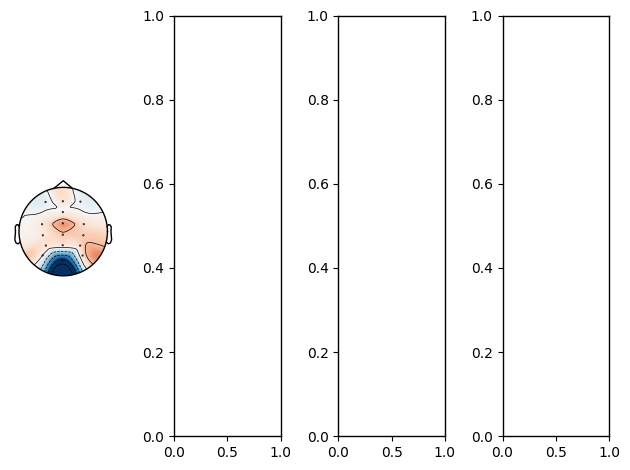

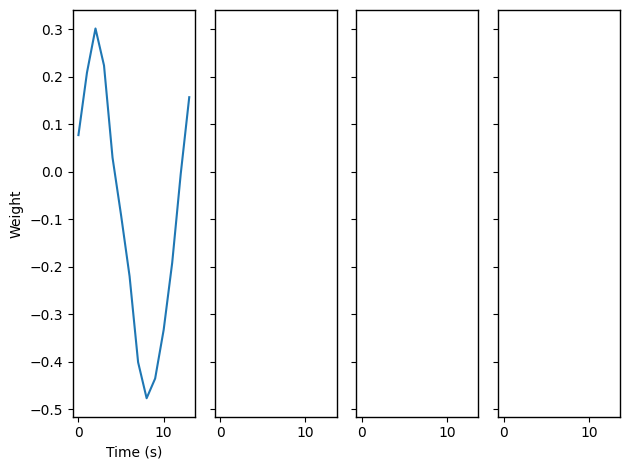

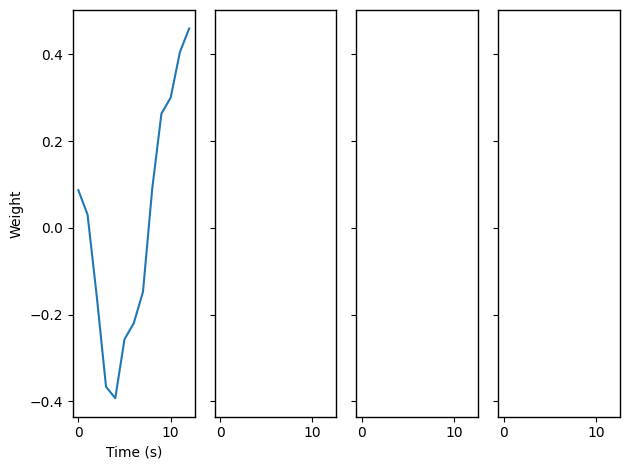

In [39]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');

n_row = int( np.ceil(hoda.rank_[2] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[2]):
    w = tl.to_numpy(hoda.scalings_[2][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


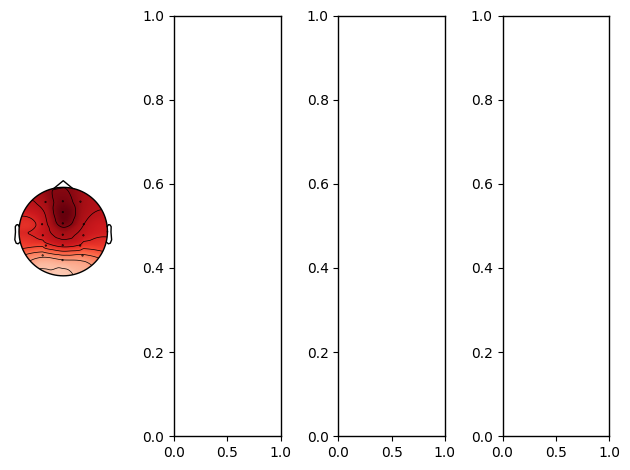

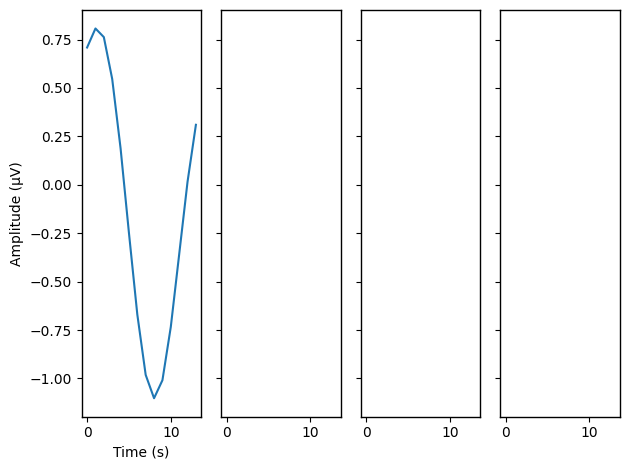

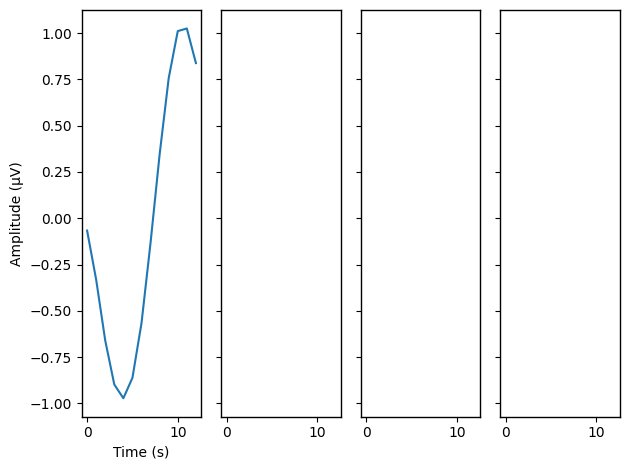

In [40]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)')

n_row = int(np.ceil(hoda.rank_[2] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[2]
for i in range(hoda.rank_[2]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

AttributeError: 'HODA' object has no attribute 'cov_w_'

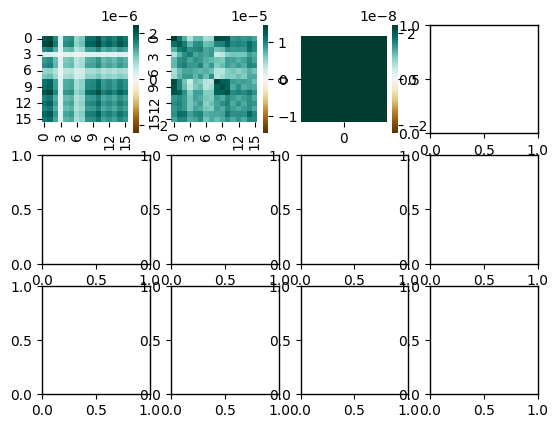

In [41]:
_, axs = plt.subplots(3,4,)
for k in range(3):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  tl.to_numpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [42]:
Xt = hoda.transform(X)

In [43]:
from hoda.hoda import f_oneway
from hoda.gpu_opt import combine_pvalues

import matplotlib
matplotlib.rcParams['axes.linewidth'] = 1
F, p = f_oneway(Xt,y)

p

array([[[2.76474243e-24]]])

In [44]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA


order = np.argsort(-F.flatten())
Xt_viz = Xt.reshape((Xt.shape[0],-1))
n_components = min(2, math.prod(Xt.shape[1:]))
Xt_viz = tl.to_numpy((Xt_viz[:,order[:n_components]]))

In [45]:
import re, seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
c = np.vectorize(cmap.get)(y)

if Xt_viz.shape[-1] < 2:
    pass
elif Xt_viz.shape[-1] <3:
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0],Xt_viz[:,1], c=c)   

ax.set_aspect('equal')


No projector specified for this dataset. Please consider the method self.add_proj.


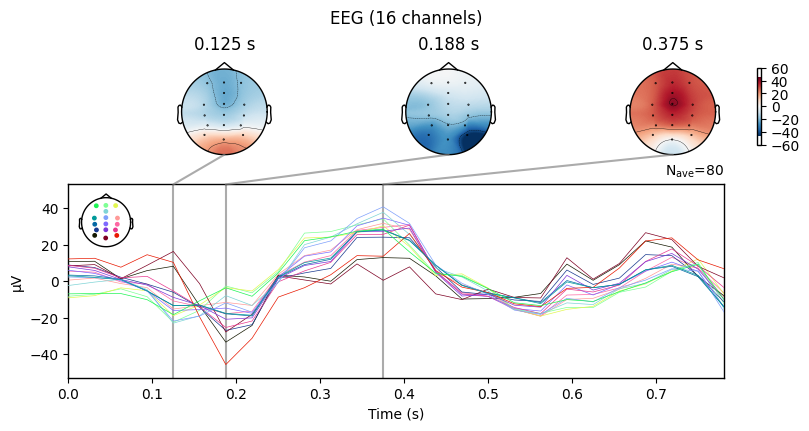

(576, 16, 26)
(576, 16, 26)
No projector specified for this dataset. Please consider the method self.add_proj.


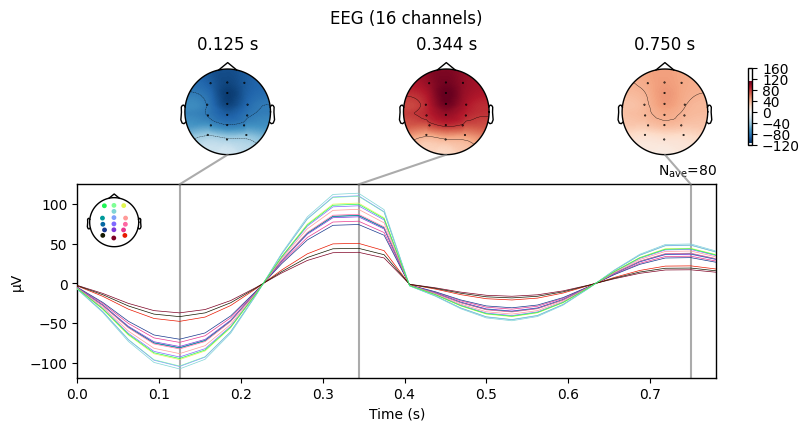

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_3456/2067173369.py:31: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_defl._data -= epochs_rec.get_data()


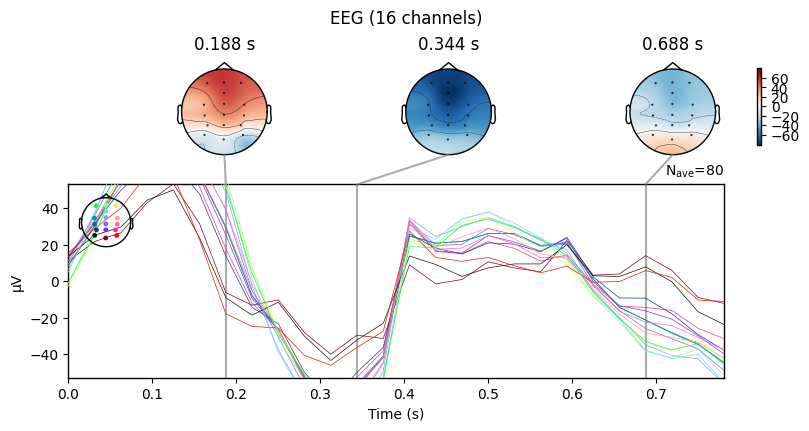

In [46]:
from mne import combine_evoked
from hoda.tensorize import hankel_tensor_inv

target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
vmax = np.max(np.abs(target.data))
vmax = max(vmax, np.max(np.abs(non_target.data)))
vmax *=1.1e6

joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-vmax,vmax]),
        unit=True,
    )
)


contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hankel_tensor_inv(hoda.inv_transform(Xt)))
print(epochs._data.shape)
print(epochs_rec._data.shape)
target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_rec.plot_joint()

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast_defl = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_defl.plot_joint(**joint_args)

## Classification

0.8029079861111112


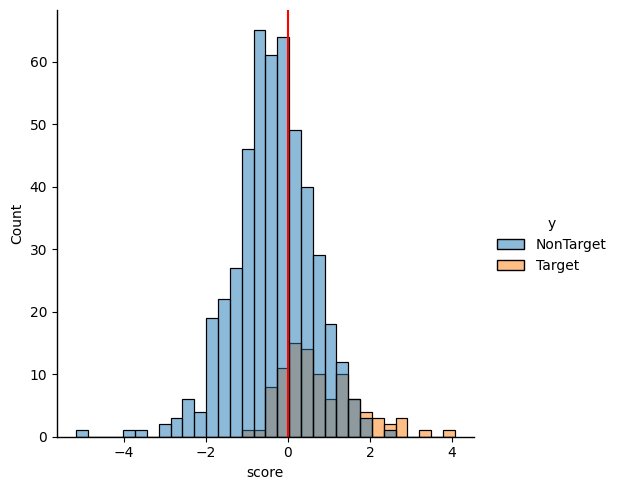

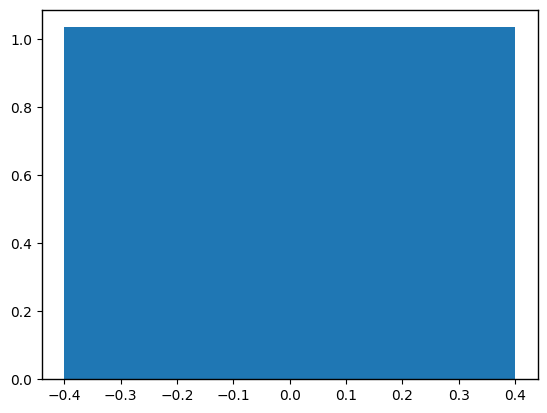

In [47]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
Xt_flat = StandardScaler().fit_transform(Xt_flat)
clf = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', class_weight='balanced', scoring='roc_auc')
clf.fit(Xt_flat, y)
score_pred = clf.decision_function(Xt_flat)


df = pd.DataFrame(dict(score=score_pred,y=y))
g = sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))

fig, ax = plt.subplots(1,1)
_ = ax.bar(np.arange(Xt_flat.shape[1]), np.abs(clf.coef_.squeeze()))